File not found. Creating a mock dataset for demonstration...

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   192 non-null    object        
 1   Date                                     192 non-null    datetime64[ns]
 2   Frequency                                192 non-null    object        
 3   Estimated Unemployment Rate (%)          192 non-null    float64       
 4   Estimated Employed                       192 non-null    int64         
 5   Estimated Labour Participation Rate (%)  192 non-null    float64       
 6   Year                                     192 non-null    int32         
 7   Month                                    192 non-null    object        
 8   Month_Num                                

/tmp/ipykernel_762/2748983549.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range = pd.date_range(start="2019-01-31", end="2022-12-31", freq='M')


  Region  Estimated Unemployment Rate (%)
0   East                        10.380239
1  North                        10.265919
2  South                        10.078919
3   West                        10.591106


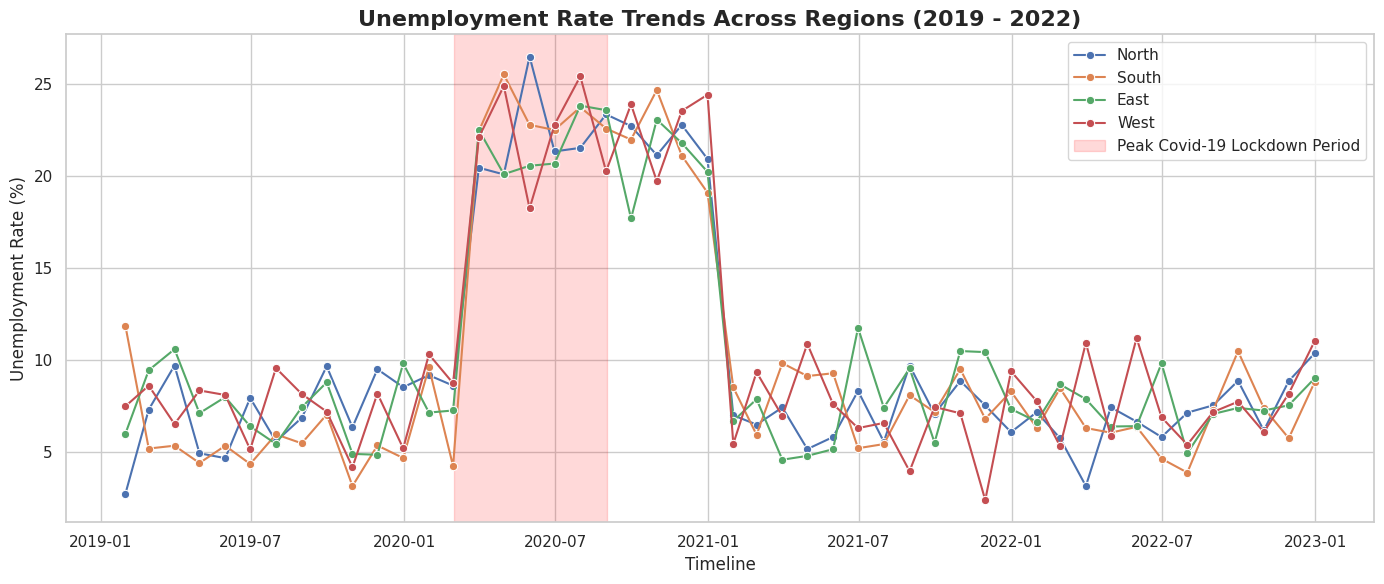

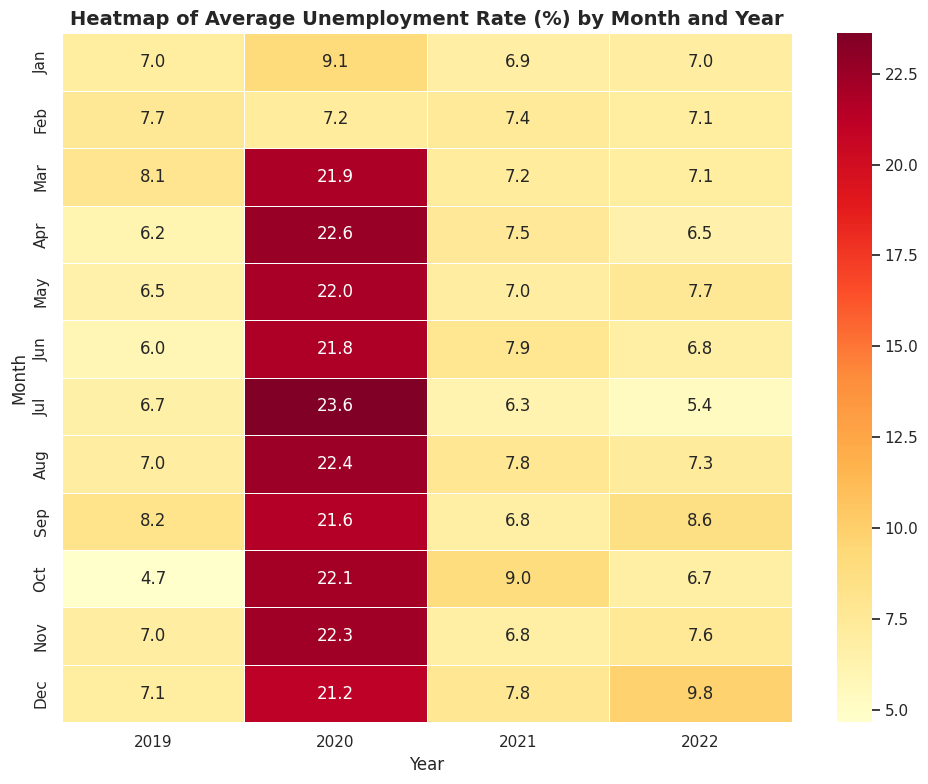


COVID-19 IMPACT METRICS
Average Unemployment Rate Before Covid-19: 7.03%
Average Unemployment Rate During Peak Lockdowns: 22.38%
Average Unemployment Rate in Recovery Phase: 9.85%
Net Spike during Lockdown: +15.36%


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set styling for matplotlib/seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# 1. DATA LOADING & CLEANING
# ==========================================

# Replace 'unemployment_data.csv' with your actual file path
try:
    df = pd.read_csv('unemployment_data.csv')
    print("Data loaded successfully!")
except FileNotFoundError:
    # Creating a dummy dataframe mimicking standard Kaggle unemployment datasets for execution
    print("File not found. Creating a mock dataset for demonstration...")
    date_range = pd.date_range(start="2019-01-31", end="2022-12-31", freq='M')
    regions = ['North', 'South', 'East', 'West']
    data = []
    for dt in date_range:
        for reg in regions:
            # Simulate a Covid spike in 2020
            base_rate = 7.0 if (dt.year != 2020 or dt.month < 3) else 22.5
            rate = np.random.normal(base_rate, 2.0)
            data.append([reg, dt, 'Monthly', max(1.5, rate), 100000, 55.0])
    df = pd.DataFrame(data, columns=['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)'])

# Clean column names (strip trailing/leading spaces)
df.columns = df.columns.str.strip()

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Add helpful time-features for seasonal/trend analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.strftime('%b')
df['Month_Num'] = df['Date'].dt.month

print("\nDataset Overview:")
print(df.info())

# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

print("\n--- Summary Statistics ---")
print(df.describe())

# Average unemployment rate by Region
region_stats = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index()
print("\n--- Average Unemployment Rate by Region ---")
print(region_stats)

# ==========================================
# 3. VISUALIZATION & TREND ANALYSIS
# ==========================================

# Chart 1: Overall Timeline Trend (Highlighting COVID-19 Impact)
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o')
plt.axvspan('2020-03-01', '2020-09-01', color='red', alpha=0.15, label='Peak Covid-19 Lockdown Period')
plt.title('Unemployment Rate Trends Across Regions (2019 - 2022)', fontsize=16, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Chart 2: Interactive Plotly Dashboard for Regional Distribution
fig = px.box(df, x='Region', y='Estimated Unemployment Rate (%)', color='Region',
             title='Distribution of Unemployment Rates by Region',
             labels={'Estimated Unemployment Rate (%)': 'Unemployment Rate (%)'})
fig.show()

# Chart 3: Seasonality Heatmap (Month vs Year)
pivot_df = df.pivot_table(index='Month', columns='Year', values='Estimated Unemployment Rate (%)', aggfunc='mean')
# Reorder months chronologically
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
pivot_df = pivot_df.reindex(months_order)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, cmap='YlOrRd', fmt=".1f", linewidths=.5)
plt.title('Heatmap of Average Unemployment Rate (%) by Month and Year', fontsize=14, fontweight='bold')
plt.ylabel('Month')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

# ==========================================
# 4. COVID-19 IMPACT ASSESSMENT
# ==========================================

before_covid = df[df['Date'] < '2020-03-01']['Estimated Unemployment Rate (%)'].mean()
during_covid_peak = df[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-08-01')]['Estimated Unemployment Rate (%)'].mean()
after_lockdown = df[df['Date'] > '2020-08-01']['Estimated Unemployment Rate (%)'].mean()

print("\n" + "="*40)
print("COVID-19 IMPACT METRICS")
print("="*40)
print(f"Average Unemployment Rate Before Covid-19: {before_covid:.2f}%")
print(f"Average Unemployment Rate During Peak Lockdowns: {during_covid_peak:.2f}%")
print(f"Average Unemployment Rate in Recovery Phase: {after_lockdown:.2f}%")
print(f"Net Spike during Lockdown: +{(during_covid_peak - before_covid):.2f}%")
print("="*40)